## Breadth-first Search

In [ ]:
from collections import deque
from typing import Dict, List, Tuple, Optional
import networkx as nx
import matplotlib.pyplot as plt

# Graph type definition: Graphs are represented as adjacency lists
Graph = Dict[str, List[str]]

def reconstruct_path(parent: Dict[str, Optional[str]], start: str, goal: str) -> List[str]:
  """
  Reconstructs the path from start to goal using the parent map.
  Returns an empty list if no path exists.
  """
  if goal not in parent:
    return []  # No path found if goal not in parent map

  path = []
  node = goal

  while node is not None:
    path.append(node)  # Build path backwards from goal to start
    node = parent.get(node)  # Move to parent

  path.reverse()  # Reverse to get start-to-goal order

  return path if path and path[0] == start else []  # Ensure path starts from start, else empty

def bfs_path(graph: Graph, start: str, goal: str) -> Tuple[List[str], List[str]]:
  """
  Breadth First Search that returns the visit order and the shortest path (in edges) from start to goal.
  Assumes an unweighted graph. If goal unreachable, path is [].
  BFS explores level by level, ensuring the shortest path in terms of number of edges.
  Uses a queue (deque for efficiency) and a set for visited nodes to avoid revisits.
  """
  visited = set([start])  # Set to track visited nodes, starting with start
  order = []  # List to record the order of visitation
  parent = {start: None}  # Dictionary to track parent of each node for path reconstruction
  q = deque([start])  # Queue initialized with start node

  while q:
    u = q.popleft()  # Dequeue the next node (FIFO for level-order)
    order.append(u)  # Record visitation

    if u == goal:
      break  # Stop if goal is found (shortest path guaranteed)

    for v in graph.get(u, []):  # For each neighbor of u
      if v not in visited:
        visited.add(v)  # Mark as visited
        parent[v] = u  # Set parent
        q.append(v)  # Enqueue

  # Reconstruct and return path if goal reached, else empty
  return order, reconstruct_path(parent, start, goal)

def visualize_traversal(graph: Graph, order: List[str], path: List[str], title: str):
  """
  Visualizes the graph traversal using NetworkX and Matplotlib.
  - Nodes are colored based on visitation order (earlier: blue, later: red).
  - Path edges are highlighted in red and thicker.
  """
  G = nx.Graph(graph)  # Create NetworkX graph from adjacency list

  # Position nodes using spring layout for better visualization
  pos = nx.spring_layout(G)

  # Color nodes based on visitation order
  if order:
    color_map = [0] * len(G.nodes())
    for i, node in enumerate(order):
      if node in G.nodes():
        color_map[list(G.nodes()).index(node)] = i / len(order)  # Normalize to 0-1 for colormap
    node_colors = plt.cm.coolwarm(color_map)  # Use coolwarm colormap: blue early, red late
  else:
    node_colors = 'lightblue'

  # Draw the graph
  nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500, font_size=10, font_weight='bold')

  # Highlight the path edges if path exists
  if path:
    path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

  plt.title(title)
  plt.show()

# Example usage (from PDF graph1)
graph1 = {
  'A': ['B', 'C'],
  'B': ['A', 'D', 'E'],
  'C': ['A', 'D', 'G'],
  'D': ['B', 'C', 'F'],
  'E': ['B'],
  'F': ['D', 'G', 'H'],
  'G': ['C', 'F'],
  'H': ['F']
}

order_bfs, path_bfs = bfs_path(graph1, 'A', 'G')

print("BFS Visitation sequence:", order_bfs)
print("BFS Shortest path in number of edges from A to G:", path_bfs)

# Visualize BFS traversal
visualize_traversal(graph1, order_bfs, path_bfs, "BFS Traversal from A to G")

## Depth-first Search

In [ ]:
from typing import Dict, List, Tuple, Optional
import networkx as nx
import matplotlib.pyplot as plt

# Graph type definition: Graphs are represented as adjacency lists
Graph = Dict[str, List[str]]

# reconstruct_path function (same as above for BFS)
def reconstruct_path(parent: Dict[str, Optional[str]], start: str, goal: str) -> List[str]:
  """
  Reconstructs the path from start to goal using the parent map.
  Returns an empty list if no path exists.
  """
  if goal not in parent:
    return []  # No path found if goal not in parent map

  path = []
  node = goal

  while node is not None:
    path.append(node)  # Build path backwards from goal to start
    node = parent.get(node)  # Move to parent

  path.reverse()  # Reverse to get start-to-goal order

  return path if path and path[0] == start else []  # Ensure path starts from start, else empty

def dfs_path(graph: Graph, start: str, goal: str) -> Tuple[List[str], List[str]]:
  """
  Depth First Search (recursive) returning visit order and the path from start to goal (first found).
  DFS explores as far as possible along each branch before backtracking.
  Not guaranteed to find the shortest path; may not be complete in infinite spaces.
  Uses recursion, a set for visited, and a parent map for path reconstruction.
  """
  visited = set()  # Set to track visited nodes
  order = []  # List to record the order of visitation
  parent: Dict[str, Optional[str]] = {start: None}  # Parent map for path
  found = False  # Flag to indicate if goal is found

  def rec(u: str):
      """
      Recursive helper function for DFS.
      Stops if goal found or branch exhausted.
      """
      nonlocal found  # Modify the found flag in the parent's scope

      if found:
        return  # Early return if goal already found

      visited.add(u)  # Mark as visited
      order.append(u)  # Record visitation

      if u == goal:
        found = True  # Goal found
        return  # Stop recursion

      for v in graph.get(u, []):  # For each neighbor
        if v not in visited:
          parent[v] = u  # Set parent
          rec(v)  # Recurse deeper

  rec(start)  # Start recursion from start node

  # Reconstruct path only if found, else empty
  path = reconstruct_path(parent, start, goal) if found else []
  return order, path

def visualize_traversal(graph: Graph, order: List[str], path: List[str], title: str):
  """
  Visualizes the graph traversal using NetworkX and Matplotlib.
  - Nodes are colored based on visitation order (earlier: blue, later: red).
  - Path edges are highlighted in red and thicker.
  """
  G = nx.Graph(graph)  # Create NetworkX graph from adjacency list

  # Position nodes using spring layout for better visualization
  pos = nx.spring_layout(G)

  # Color nodes based on visitation order
  if order:
    color_map = [0] * len(G.nodes())
    for i, node in enumerate(order):
      if node in G.nodes():
        color_map[list(G.nodes()).index(node)] = i / len(order)  # Normalize to 0-1 for colormap
    node_colors = plt.cm.coolwarm(color_map)  # Use coolwarm colormap: blue early, red late
  else:
    node_colors = 'lightblue'

  # Draw the graph
  nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500, font_size=10, font_weight='bold')

  # Highlight the path edges if path exists
  if path:
    path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

  plt.title(title)
  plt.show()

# Example usage (from PDF graph1)
graph1 = {
  'A': ['B', 'C'],
  'B': ['A', 'D', 'E'],
  'C': ['A', 'D', 'G'],
  'D': ['B', 'C', 'F'],
  'E': ['B'],
  'F': ['D', 'G', 'H'],
  'G': ['C', 'F'],
  'H': ['F']
}

order_dfs, path_dfs = dfs_path(graph1, 'A', 'G')

print("DFS Visitation sequence:", order_dfs)
print("DFS Path from A to G:", path_dfs)

# Visualize DFS traversal
visualize_traversal(graph1, order_dfs, path_dfs, "DFS Traversal from A to G")

## Depth-limit Search

DLS Visitation sequence: ['S', 'A', 'C', 'E', 'F', 'D', 'G']
DLS Path from S to G (with limit = 2): ['S', 'A', 'D', 'G']


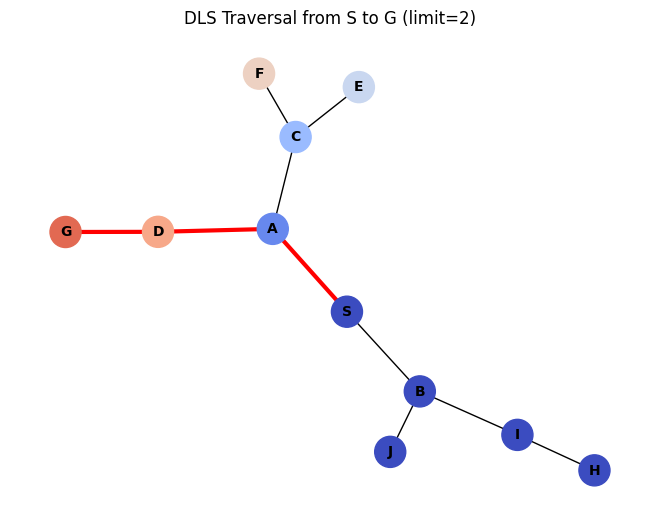

In [8]:
from typing import Dict, List, Tuple, Optional
import networkx as nx
import matplotlib.pyplot as plt

# Graph type definition: Graphs are represented as adjacency lists
Graph = Dict[str, List[str]]

# reconstruct_path function (same as above for BFS/DFS)
def reconstruct_path(parent: Dict[str, Optional[str]], start: str, goal: str) -> List[str]:
  """
  Reconstructs the path from start to goal using the parent map.
  Returns an empty list if no path exists.
  """
  if goal not in parent:
    return []  # No path found if goal not in parent map

  path = []
  node = goal

  while node is not None:
    path.append(node)  # Build path backwards from goal to start
    node = parent.get(node)  # Move to parent

  path.reverse()  # Reverse to get start-to-goal order
  return path if path and path[0] == start else []  # Ensure path starts from start, else empty

def dls(graph: Graph, start: str, goal: str, limit: int) -> Tuple[List[str], List[str]]:
  """
  Depth Limited Search. Returns (order, path) if goal found within limit, else (order, []).
  DLS is a variant of DFS that limits the depth of exploration to avoid infinite loops in deep/infinite spaces.
  Uses recursion with a decrementing limit on each recursive call.
  Stops expanding a branch when limit < 0.
  Tracks visited to avoid cycles, order for visitation sequence, and parent for path reconstruction.
  """
  visited = set()  # Set to track visited nodes
  order = []  # List to record the order of visitation
  parent: Dict[str, Optional[str]] = {start: None}  # Parent map for path
  found = False  # Flag to indicate if goal is found

  def rec(u: str, lim: int):
    """
    Recursive helper for DLS.
    Takes current node and remaining limit.
    Stops if found, limit < 0, or branch exhausted.
    """
    nonlocal found  # Modify found in parent's scope

    if found or lim < 0:
      return  # Early return if goal found or limit exceeded

    visited.add(u)  # Mark as visited
    order.append(u)  # Record visitation

    if u == goal:
      found = True  # Goal found
      return  # Stop recursion

    for v in graph.get(u, []):  # For each neighbor
      if v not in visited:
        parent[v] = u  # Set parent
        rec(v, lim - 1)  # Recurse with decremented limit

  rec(start, limit)  # Start recursion with initial limit
  # Reconstruct path only if found, else empty

  path = reconstruct_path(parent, start, goal) if found else []
  return order, path

def visualize_traversal(graph: Graph, order: List[str], path: List[str], title: str):
  """
  Visualizes the graph traversal using NetworkX and Matplotlib.
  - Nodes are colored based on visitation order (earlier: blue, later: red).
  - Path edges are highlighted in red and thicker.
  """
  G = nx.Graph(graph)  # Create NetworkX graph from adjacency list

  # Position nodes using spring layout for better visualization
  pos = nx.spring_layout(G)

  # Color nodes based on visitation order
  if order:
    color_map = [0] * len(G.nodes())
    for i, node in enumerate(order):
      if node in G.nodes():
        color_map[list(G.nodes()).index(node)] = i / len(order)  # Normalize to 0-1 for colormap
    node_colors = plt.cm.coolwarm(color_map)  # Use coolwarm colormap: blue early, red late
  else:
    node_colors = 'lightblue'

  # Draw the graph
  nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500, font_size=10, font_weight='bold')

  # Highlight the path edges if path exists
  if path:
    path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

  plt.title(title)
  plt.show()

# Example usage (from PDF graph_dls)
graph_dls = {
  'S': ['A', 'B'],
  'A': ['C', 'D'],
  'B': ['I', 'J'],
  'C': ['E', 'F'],
  'D': ['G'],
  'I': ['H'],
}

order_dls, path_dls = dls(graph_dls, 'S', 'G', limit = 3)
print("DLS Visitation sequence:", order_dls)
print("DLS Path from S to G (with limit = 2):", path_dls)

# Visualize DLS traversal
visualize_traversal(graph_dls, order_dls, path_dls, "DLS Traversal from S to G (limit=2)")

## Iterative Deepening Search

IDS Visitation sequence (final iteration): ['S', 'A', 'C', 'E', 'F', 'D', 'G']
IDS Path from S to G: ['S', 'A', 'D', 'G']


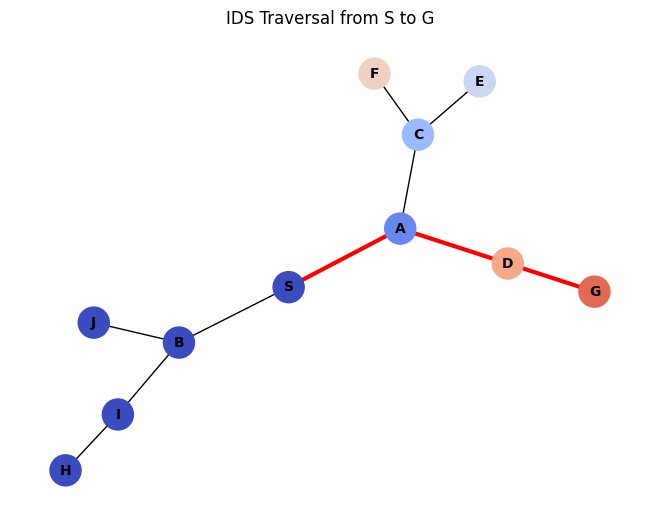

In [9]:
from typing import Dict, List, Tuple, Optional
import networkx as nx
import matplotlib.pyplot as plt

# Graph type definition: Graphs are represented as adjacency lists
Graph = Dict[str, List[str]]

# reconstruct_path function
def reconstruct_path(parent: Dict[str, Optional[str]], start: str, goal: str) -> List[str]:
    """
    Reconstructs the path from start to goal using the parent map.
    Returns an empty list if no path exists.
    """
    if goal not in parent:
        return []  # No path found if goal not in parent map
    path = []
    node = goal
    while node is not None:
        path.append(node)  # Build path backwards from goal to start
        node = parent.get(node)  # Move to parent
    path.reverse()  # Reverse to get start-to-goal order
    return path if path and path[0] == start else []  # Ensure path starts from start, else empty

def dls(graph: Graph, start: str, goal: str, limit: int) -> Tuple[List[str], List[str]]:
    """
    Depth Limited Search. Returns (order, path) if goal found within limit, else (order, []).
    DLS is a variant of DFS that limits the depth of exploration to avoid infinite loops in deep/infinite spaces.
    Uses recursion with a decrementing limit on each recursive call.
    Stops expanding a branch when limit < 0.
    Tracks visited to avoid cycles, order for visitation sequence, and parent for path reconstruction.
    """
    visited = set()  # Set to track visited nodes
    order = []  # List to record the order of visitation
    parent: Dict[str, Optional[str]] = {start: None}  # Parent map for path
    found = False  # Flag to indicate if goal is found

    def rec(u: str, lim: int):
        """
        Recursive helper for DLS.
        Takes current node and remaining limit.
        Stops if found, limit < 0, or branch exhausted.
        """
        nonlocal found  # Modify found in parent's scope
        if found or lim < 0:
            return  # Early return if goal found or limit exceeded
        visited.add(u)  # Mark as visited
        order.append(u)  # Record visitation
        if u == goal:
            found = True  # Goal found
            return  # Stop recursion
        for v in graph.get(u, []):  # For each neighbor
            if v not in visited:
                parent[v] = u  # Set parent
                rec(v, lim - 1)  # Recurse with decremented limit

    rec(start, limit)  # Start recursion with initial limit
    # Reconstruct path only if found, else empty
    path = reconstruct_path(parent, start, goal) if found else []
    return order, path

def ids(graph: Graph, start: str, goal: str) -> Tuple[List[str], List[str]]:
    """
    Iterative Deepening Search. Returns (order, path) from the successful depth limit.
    IDS combines the benefits of BFS (optimal, complete) and DFS (space-efficient) by iteratively increasing the depth limit.
    It calls DLS with increasing limits until the goal is found.
    The visitation order returned is from the final successful DLS call (note: in practice, upper levels are re-visited multiple times across iterations).
    """
    depth = 0
    while True:
        order, path = dls(graph, start, goal, depth)
        if path:  # Goal found at this depth
            return order, path
        depth += 1  # Increase depth limit

def visualize_traversal(graph: Graph, order: List[str], path: List[str], title: str):
    """
    Visualizes the graph traversal using NetworkX and Matplotlib.
    - Nodes are colored based on visitation order (earlier: blue, later: red).
    - Path edges are highlighted in red and thicker.
    - If graph is weighted (neighbors as list of (str, int)), shows edge labels with weights.
    """
    G = nx.Graph()
    for u in graph:
        for neigh in graph[u]:
            if isinstance(neigh, tuple):
                v, w = neigh
                G.add_edge(u, v, weight=w)
            else:
                v = neigh
                G.add_edge(u, v)

    # Position nodes using spring layout for better visualization
    pos = nx.spring_layout(G)

    # Color nodes based on visitation order
    if order:
        color_map = [0] * len(G.nodes())
        for i, node in enumerate(order):
            if node in G.nodes():
                color_map[list(G.nodes()).index(node)] = i / len(order)  # Normalize to 0-1 for colormap
        node_colors = plt.cm.coolwarm(color_map)  # Use coolwarm colormap: blue early, red late
    else:
        node_colors = 'lightblue'

    # Draw the graph
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500, font_size=10, font_weight='bold')

    # Draw edge labels if weighted
    edge_labels = nx.get_edge_attributes(G, 'weight')
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    # Highlight the path edges if path exists
    if path:
        path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title(title)
    plt.show()

# Example usage (using graph_dls from PDF, goal at depth 3)
graph_dls = {
    'S': ['A', 'B'],
    'A': ['C', 'D'],
    'B': ['I', 'J'],
    'C': ['E', 'F'],
    'D': ['G'],
    'I': ['H'],
}
order_ids, path_ids = ids(graph_dls, 'S', 'G')
print("IDS Visitation sequence (final iteration):", order_ids)
print("IDS Path from S to G:", path_ids)

# Visualize IDS traversal
visualize_traversal(graph_dls, order_ids, path_ids, "IDS Traversal from S to G")

## Uniform Cost Search

UCS Visitation sequence: ['A', 'B', 'D', 'C', 'F', 'E', 'G']
UCS Lowest cost path from A to G: ['A', 'B', 'D', 'F', 'G']


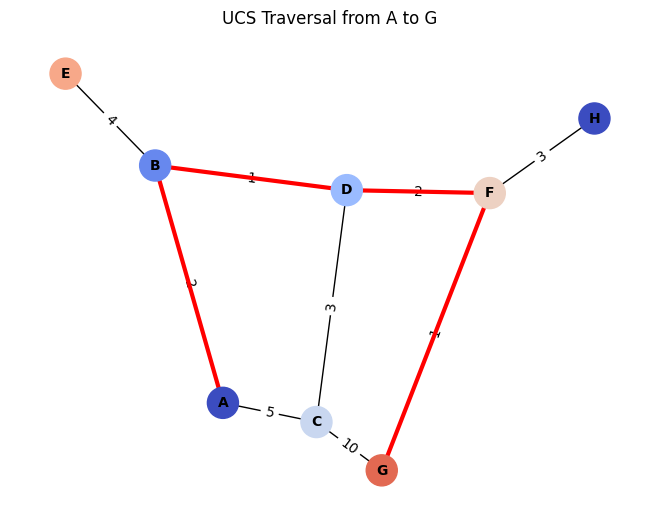

In [12]:
from typing import Dict, List, Tuple, Optional
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Weighted Graph type: Dict[str, List[Tuple[str, int]]]
WeightedGraph = Dict[str, List[Tuple[str, int]]]

# reconstruct_path function
def reconstruct_path(parent: Dict[str, Optional[str]], start: str, goal: str) -> List[str]:
    """
    Reconstructs the path from start to goal using the parent map.
    Returns an empty list if no path exists.
    """
    if goal not in parent:
        return []  # No path found if goal not in parent map
    path = []
    node = goal
    while node is not None:
        path.append(node)  # Build path backwards from goal to start
        node = parent.get(node)  # Move to parent
    path.reverse()  # Reverse to get start-to-goal order
    return path if path and path[0] == start else []  # Ensure path starts from start, else empty

def ucs(graph: WeightedGraph, start: str, goal: str) -> Tuple[List[str], List[str]]:
    """
    Uniform Cost Search. Returns (order, path) where path is the lowest cost path.
    UCS expands the lowest cost node first using a priority queue.
    Optimal for graphs with non-negative edge costs.
    Assumes weighted graph. Visitation order is the order nodes are dequeued (expanded).
    """
    visited = set()  # Set to track visited nodes
    order = []  # List to record the order of visitation (expansion)
    parent: Dict[str, Optional[str]] = {start: None}  # Parent map for path
    g_cost = {start: 0}  # Cost from start to node
    pq = []  # Priority queue: (cost, node)
    heapq.heappush(pq, (0, start))

    while pq:
        cost, u = heapq.heappop(pq)  # Pop lowest cost
        if u in visited:
            continue  # Skip if already visited (better cost found earlier)
        visited.add(u)
        order.append(u)  # Record expansion
        if u == goal:
            break  # Found goal with minimal cost
        for v, w in graph.get(u, []):  # For each neighbor and weight
            new_cost = g_cost[u] + w
            if v not in g_cost or new_cost < g_cost[v]:  # Better path
                g_cost[v] = new_cost
                parent[v] = u
                heapq.heappush(pq, (new_cost, v))  # Push with new cost

    path = reconstruct_path(parent, start, goal)
    return order, path

def visualize_traversal(graph, order: List[str], path: List[str], title: str):
    """
    Visualizes the graph traversal using NetworkX and Matplotlib.
    - Nodes are colored based on visitation order (earlier: blue, later: red).
    - Path edges are highlighted in red and thicker.
    - If graph is weighted (neighbors as list of (str, int)), shows edge labels with weights.
    """
    G = nx.Graph()
    for u in graph:
        for neigh in graph[u]:
            if isinstance(neigh, tuple):
                v, w = neigh
                G.add_edge(u, v, weight=w)
            else:
                v = neigh
                G.add_edge(u, v)

    # Position nodes using spring layout for better visualization
    pos = nx.spring_layout(G)

    # Color nodes based on visitation order
    if order:
        color_map = [0] * len(G.nodes())
        for i, node in enumerate(order):
            if node in G.nodes():
                color_map[list(G.nodes()).index(node)] = i / len(order)  # Normalize to 0-1 for colormap
        node_colors = plt.cm.coolwarm(color_map)  # Use coolwarm colormap: blue early, red late
    else:
        node_colors = 'lightblue'

    # Draw the graph
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500, font_size=10, font_weight='bold')

    # Draw edge labels if weighted
    edge_labels = nx.get_edge_attributes(G, 'weight')
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    # Highlight the path edges if path exists
    if path:
        path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title(title)
    plt.show()

# Example usage: Weighted graph based on graph1 structure with varying costs
graph_ucs = {
    'A': [('B', 2), ('C', 5)],
    'B': [('A', 2), ('D', 1), ('E', 4)],
    'C': [('A', 5), ('D', 3), ('G', 10)],
    'D': [('B', 1), ('C', 3), ('F', 2)],
    'E': [('B', 4)],
    'F': [('D', 2), ('G', 1), ('H', 3)],
    'G': [('C', 10), ('F', 1)],
    'H': [('F', 3)]
}
order_ucs, path_ucs = ucs(graph_ucs, 'A', 'G')
print("UCS Visitation sequence:", order_ucs)
print("UCS Lowest cost path from A to G:", path_ucs)

# Visualize UCS traversal
visualize_traversal(graph_ucs, order_ucs, path_ucs, "UCS Traversal from A to G")

## Bidirectional Search

Bidirectional Search Visitation sequence: ['A', 'G']
Bidirectional Search Path from A to G: ['A', 'C', 'G']


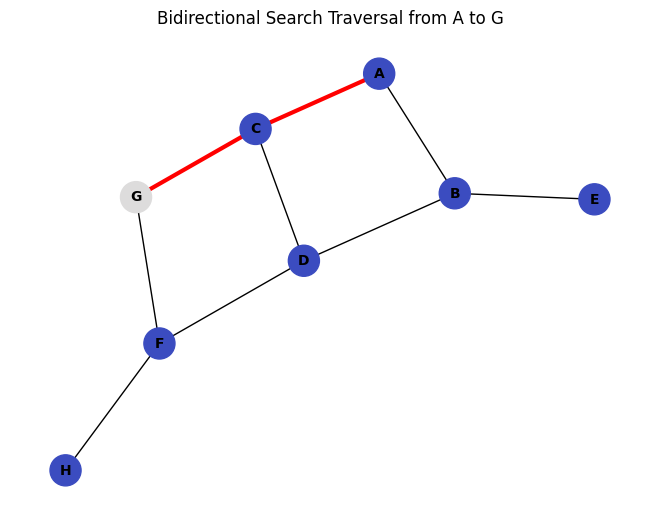

In [13]:
from collections import deque
from typing import Dict, List, Tuple, Optional
import networkx as nx
import matplotlib.pyplot as plt

# Graph type definition: Graphs are represented as adjacency lists
Graph = Dict[str, List[str]]

# reconstruct_path function for bidirectional: combines forward and backward paths at meeting point
def reconstruct_bidirectional_path(parent_forward: Dict[str, Optional[str]], parent_backward: Dict[str, Optional[str]], meet: str, start: str, goal: str) -> List[str]:
    """
    Reconstructs the full path by combining the forward path to meet and backward path from meet to goal (reversed).
    """
    # Forward path: start to meet
    path_forward = []
    node = meet
    while node is not None:
        path_forward.append(node)
        node = parent_forward.get(node)
    path_forward.reverse()

    # Backward path: meet to goal (excluding meet since already in forward)
    node = parent_backward[meet]
    while node is not None:
        path_forward.append(node)
        node = parent_backward.get(node)

    return path_forward if path_forward[0] == start and path_forward[-1] == goal else []

def bidirectional_search(graph: Graph, start: str, goal: str) -> Tuple[List[str], List[str]]:
    """
    Bidirectional Search using two BFS: one from start (forward), one from goal (backward).
    Searches simultaneously until a common node (meet) is found.
    Efficient as it reduces the branching factor.
    Assumes undirected graph. Visitation order is interleaved by dequeuing alternately from forward and backward queues.
    Returns combined order and reconstructed path.
    """
    if start == goal:
        return [start], [start]

    visited_forward = set([start])
    visited_backward = set([goal])
    order = []  # Combined visitation order
    parent_forward = {start: None}
    parent_backward = {goal: None}
    q_forward = deque([start])
    q_backward = deque([goal])

    found = False
    meet = None

    while q_forward and q_backward and not found:
        # Forward step
        if q_forward:
            u = q_forward.popleft()
            order.append(u)  # Record forward visitation
            for v in graph.get(u, []):
                if v not in visited_forward:
                    visited_forward.add(v)
                    parent_forward[v] = u
                    q_forward.append(v)
                    if v in visited_backward:  # Meet point
                        found = True
                        meet = v
                        break
        if found:
            break

        # Backward step
        if q_backward:
            u = q_backward.popleft()
            order.append(u)  # Record backward visitation
            for v in graph.get(u, []):
                if v not in visited_backward:
                    visited_backward.add(v)
                    parent_backward[v] = u
                    q_backward.append(v)
                    if v in visited_forward:  # Meet point
                        found = True
                        meet = v
                        break

    if not found or meet is None:
        return order, []  # No path

    path = reconstruct_bidirectional_path(parent_forward, parent_backward, meet, start, goal)
    return order, path

def visualize_traversal(graph, order: List[str], path: List[str], title: str):
    """
    Visualizes the graph traversal using NetworkX and Matplotlib.
    - Nodes are colored based on visitation order (earlier: blue, later: red).
    - Path edges are highlighted in red and thicker.
    - If graph is weighted (neighbors as list of (str, int)), shows edge labels with weights.
    """
    G = nx.Graph()
    for u in graph:
        for neigh in graph[u]:
            if isinstance(neigh, tuple):
                v, w = neigh
                G.add_edge(u, v, weight=w)
            else:
                v = neigh
                G.add_edge(u, v)

    # Position nodes using spring layout for better visualization
    pos = nx.spring_layout(G)

    # Color nodes based on visitation order
    if order:
        color_map = [0] * len(G.nodes())
        for i, node in enumerate(order):
            if node in G.nodes():
                color_map[list(G.nodes()).index(node)] = i / len(order)  # Normalize to 0-1 for colormap
        node_colors = plt.cm.coolwarm(color_map)  # Use coolwarm colormap: blue early, red late
    else:
        node_colors = 'lightblue'

    # Draw the graph
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500, font_size=10, font_weight='bold')

    # Draw edge labels if weighted
    edge_labels = nx.get_edge_attributes(G, 'weight')
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    # Highlight the path edges if path exists
    if path:
        path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title(title)
    plt.show()

# Example usage (using graph1 from PDF)
graph1 = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'D', 'G'],
    'D': ['B', 'C', 'F'],
    'E': ['B'],
    'F': ['D', 'G', 'H'],
    'G': ['C', 'F'],
    'H': ['F']
}
order_bi, path_bi = bidirectional_search(graph1, 'A', 'G')
print("Bidirectional Search Visitation sequence:", order_bi)
print("Bidirectional Search Path from A to G:", path_bi)

# Visualize Bidirectional traversal
visualize_traversal(graph1, order_bi, path_bi, "Bidirectional Search Traversal from A to G")